In [1]:
import os

#os.environ["DGLBACKEND"] = "pytorch"
import dgl
import dgl.data
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt

look inside in graphConv

In [2]:
from dgl.nn import GraphConv

In [3]:
g = dgl.graph(([0,1,2,3,2,5], [1,2,3,4,0,3]))
g = dgl.add_self_loop(g)

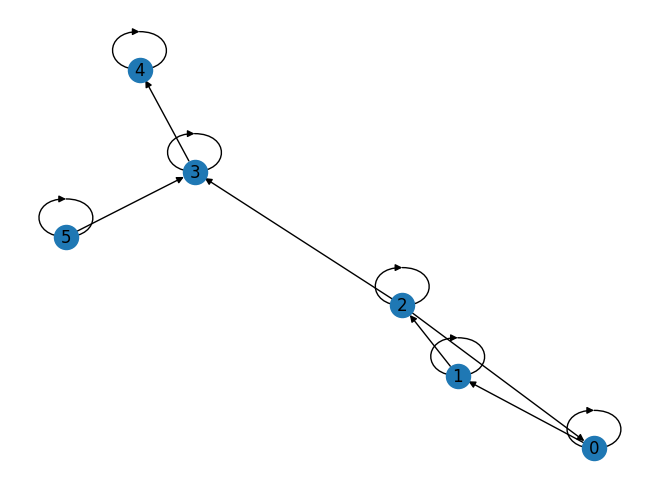

In [4]:
G = dgl.to_networkx(g)
nx.draw(G, with_labels=True)

In [6]:
for n in G:
    print(n)

0
1
2
3
4
5


In [49]:
# Create a heterograph with 3 node types and 3 edges types.
graph_data = {
   ('drug', 'interacts', 'drug'): (torch.tensor([0, 1]), torch.tensor([1, 2])),
   ('drug', 'interacts', 'gene'): (torch.tensor([0, 1]), torch.tensor([2, 3])),
   ('drug', 'treats', 'disease'): (torch.tensor([1]), torch.tensor([2]))
}

In [50]:
g = dgl.heterograph(graph_data)

In [51]:
g

Graph(num_nodes={'disease': 3, 'drug': 3, 'gene': 4},
      num_edges={('drug', 'interacts', 'drug'): 2, ('drug', 'interacts', 'gene'): 2, ('drug', 'treats', 'disease'): 1},
      metagraph=[('drug', 'drug', 'interacts'), ('drug', 'gene', 'interacts'), ('drug', 'disease', 'treats')])

In [55]:
g.ntypes

['disease', 'drug', 'gene']

In [56]:
g.etypes

['interacts', 'interacts', 'treats']

In [57]:
g.canonical_etypes

[('drug', 'interacts', 'drug'),
 ('drug', 'interacts', 'gene'),
 ('drug', 'treats', 'disease')]

In [58]:
g.num_nodes('drug')

3

In [59]:
g.nodes('drug')

tensor([0, 1, 2])

In [54]:
print(g.nodes())

DGLError: Node type name must be specified if there are more than one node types.

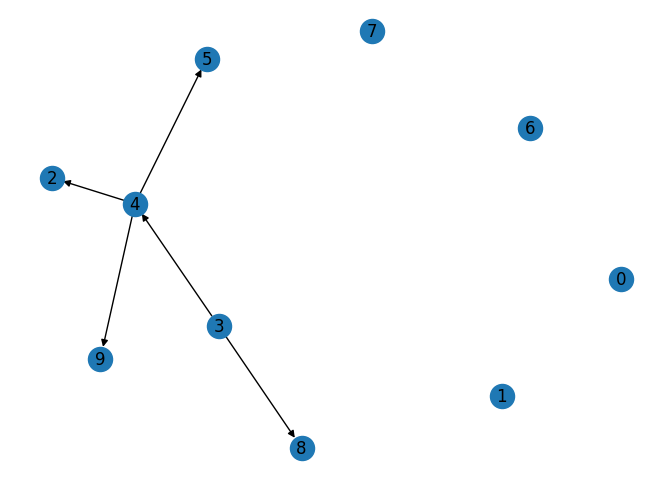

In [53]:
G = dgl.to_networkx(g)
nx.draw(G, with_labels=True)

In [62]:
#networkx bipartite
from networkx.algorithms import bipartite
B = nx.Graph()
B.add_nodes_from([1, 2, 3, 4], bipartite=0)
B.add_nodes_from(["a", "b", "c"], bipartite=1)
# Add edges only between nodes of opposite node sets
B.add_edges_from([(1, "a"), (1, "b"), (2, "b"), (2, "c"), (3, "c"), (4, "a")])

In [63]:
B

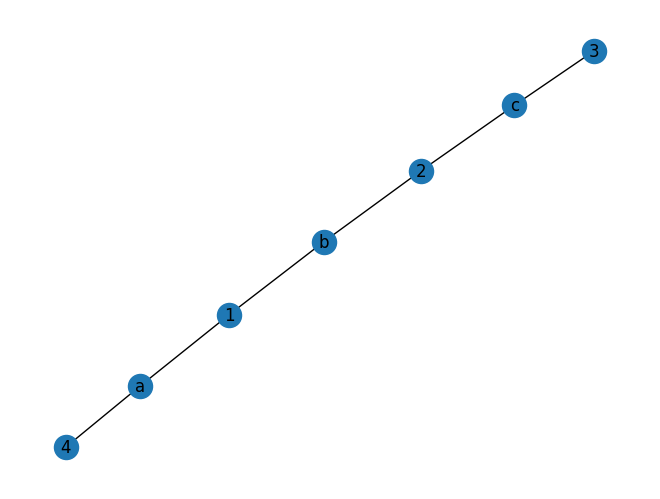

In [64]:
nx.draw(B, with_labels=True)

In [71]:
C = nx.Graph()
C.add_nodes_from([1, 2, 3, 4], bipartite=0)
C.add_nodes_from(["u1", "u2", "u3"], bipartite=1)
# Add edges only between nodes of opposite node sets
C.add_edges_from([(1, "u1"), (2, "u3"), (3, "u1"), (2, "u1"), (4,"u2")])

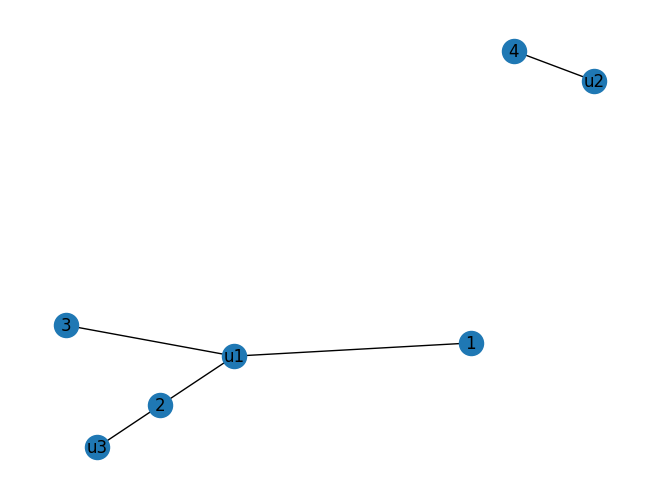

In [72]:
nx.draw(C, with_labels=True)

In [23]:
feat = torch.ones(6, 10)

In [24]:
feat

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [25]:
conv = GraphConv(10, 2, norm='both', weight=True, bias = True)

In [26]:
conv

GraphConv(in=10, out=2, normalization=both, activation=None)

In [28]:
res = conv(g, feat)
print(res)

tensor([[-0.1965, -0.7481],
        [-0.2164, -0.8237],
        [-0.1965, -0.7481],
        [-0.2488, -0.9471],
        [-0.2612, -0.9943],
        [-0.1530, -0.5824]], grad_fn=<AddBackward0>)


GCN example code with dgl

In [31]:
import numpy as np 
import dgl 
from dgl.nn import GraphConv 
 
import torch
import torch.nn as nn 
import torch.optim as optim 
import torch.nn.functional as F 

import dgl.data

In [32]:
dataset = dgl.data.CoraGraphDataset()
print('Number of Categories:', dataset.num_classes)
g = dataset[0]

print('Number of nodes:', g.num_nodes)
print('Number of edges:', g.num_edges)

  NumNodes: 2708
  NumEdges: 10556
  NumFeats: 1433
  NumClasses: 7
  NumTrainingSamples: 140
  NumValidationSamples: 500
  NumTestSamples: 1000
Done loading data from cached files.
Number of Categories: 7
Number of nodes: <bound method DGLGraph.num_nodes of Graph(num_nodes=2708, num_edges=10556,
      ndata_schemes={'feat': Scheme(shape=(1433,), dtype=torch.float32), 'label': Scheme(shape=(), dtype=torch.int64), 'test_mask': Scheme(shape=(), dtype=torch.bool), 'val_mask': Scheme(shape=(), dtype=torch.bool), 'train_mask': Scheme(shape=(), dtype=torch.bool)}
      edata_schemes={})>
Number of edges: <bound method DGLGraph.num_edges of Graph(num_nodes=2708, num_edges=10556,
      ndata_schemes={'feat': Scheme(shape=(1433,), dtype=torch.float32), 'label': Scheme(shape=(), dtype=torch.int64), 'test_mask': Scheme(shape=(), dtype=torch.bool), 'val_mask': Scheme(shape=(), dtype=torch.bool), 'train_mask': Scheme(shape=(), dtype=torch.bool)}
      edata_schemes={})>


In [33]:
g

Graph(num_nodes=2708, num_edges=10556,
      ndata_schemes={'feat': Scheme(shape=(1433,), dtype=torch.float32), 'label': Scheme(shape=(), dtype=torch.int64), 'test_mask': Scheme(shape=(), dtype=torch.bool), 'val_mask': Scheme(shape=(), dtype=torch.bool), 'train_mask': Scheme(shape=(), dtype=torch.bool)}
      edata_schemes={})

In [34]:
print('Node feature names:', g.ndata.keys())
print('Edge feature names:', g.edata.keys())


Node feature names: dict_keys(['feat', 'label', 'test_mask', 'val_mask', 'train_mask'])
Edge feature names: dict_keys([])


In [35]:
#lens of train_mask is same as number of nodes

print(g.ndata['train_mask'])
print(g.ndata['train_mask'].shape)


tensor([ True,  True,  True,  ..., False, False, False])
torch.Size([2708])


In [36]:
print('Number of training nodes:', g.ndata['train_mask'].int().sum().item())
print('Number of validating nodes:', g.ndata['val_mask'].int().sum().item())
print('Number of testing nodes:', g.ndata['test_mask'].int().sum().item())

Number of training nodes: 140
Number of validating nodes: 500
Number of testing nodes: 1000


In [37]:
print('Number of classes:', (g.ndata['label'].max()+1).item())
print('Node feature shape:', g.ndata['feat'].shape)

Number of classes: 7
Node feature shape: torch.Size([2708, 1433])


In [46]:
class GCN(nn.Module):
    def __init__(self, in_feats, n_hidden, n_classes):
        super(GCN, self).__init__()
        self.conv1 = GraphConv(in_feats, n_hidden)
        self.conv2 = GraphConv(n_hidden, n_classes)
        self.relu = nn.ReLU()
    def forward(self, g, in_feat):
        output = self.conv1(g, in_feat)
        output = self.relu(output)
        output = self.conv2(g, output)
        print('output:', output.shape)
        return output
    
models = GCN(g.ndata['feat'].shape[1], 16, dataset.num_classes)

def criterion(pred_y, true_y, mask):
    pred_y = pred_y[mask]
    true_y = true_y[mask]
    return F.cross_entropy(pred_y, true_y)

def accuracy(pred_y, true_y, mask):
    pred_y = pred_y[mask]
    true_y = true_y[mask]
    return (pred_y == true_y).float().mean()

def trainer(g, model, n_epoch, device):
    optimizer = optim.Adam(model.parameters())
    
    best_val_acc = 0
    best_test_acc = 0
    g = g.to(device)
    features = g.ndata['feat'].to(device)
    labels = g.ndata['label'].to(device)
    train_mask = g.ndata['train_mask']
    val_mask = g.ndata['val_mask']
    test_mask = g.ndata['test_mask']
    
    for epoch in range(1, n_epoch+1):
        pred_y = model(g, features).to(device)
        print('pred_y', pred_y.shape)
        loss = criterion(pred_y, labels, train_mask)
        pred_y = pred_y.argmax(1)#output dim is num of classes
        train_acc = accuracy(pred_y, labels, train_mask)
        val_acc = accuracy(pred_y, labels, val_mask)
        test_acc = accuracy(pred_y, labels, test_mask)
        
        if best_val_acc < val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

        print(f'In epoch [{epoch}/{n_epoch}]\t loss: {loss:.3f}\t train_acc: {train_acc*100:.2f}%\t val_acc: {val_acc*100:.2f}%\t test_acc: {test_acc*100:.2f}%')
        print(f'best val acc: {best_val_acc*100:.2f}%\t best test acc: {best_test_acc*100:.2f}%\n')
            

In [47]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
model = GCN(g.ndata['feat'].shape[1], 16, dataset.num_classes).to(device)

trainer(g, model, 30, device)

output: torch.Size([2708, 7])
pred_y torch.Size([2708, 7])
In epoch [1/30]	 loss: 1.946	 train_acc: 10.71%	 val_acc: 10.80%	 test_acc: 12.20%
best val acc: 10.80%	 best test acc: 12.20%

output: torch.Size([2708, 7])
pred_y torch.Size([2708, 7])
In epoch [2/30]	 loss: 1.945	 train_acc: 18.57%	 val_acc: 14.20%	 test_acc: 13.70%
best val acc: 14.20%	 best test acc: 13.70%

output: torch.Size([2708, 7])
pred_y torch.Size([2708, 7])
In epoch [3/30]	 loss: 1.945	 train_acc: 21.43%	 val_acc: 17.60%	 test_acc: 15.30%
best val acc: 17.60%	 best test acc: 15.30%

output: torch.Size([2708, 7])
pred_y torch.Size([2708, 7])
In epoch [4/30]	 loss: 1.944	 train_acc: 28.57%	 val_acc: 21.20%	 test_acc: 18.10%
best val acc: 21.20%	 best test acc: 18.10%

output: torch.Size([2708, 7])
pred_y torch.Size([2708, 7])
In epoch [5/30]	 loss: 1.943	 train_acc: 33.57%	 val_acc: 23.60%	 test_acc: 21.40%
best val acc: 23.60%	 best test acc: 21.40%

output: torch.Size([2708, 7])
pred_y torch.Size([2708, 7])
In epo